# Loading and Preprocessing Dataset

Before training the model, we need to load the dataset and remove the 'Enrolled' students. We are framing this as a binary classification problem to predict strictly between 'Dropout' and 'Graduate'.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import xgboost as xgb

# Load the dataset
df = pd.read_csv("../dataset/data.csv", sep=";")

# Remove 'Enrolled' class
df = df[df['Target'] != 'Enrolled']

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


We can see the data set loaded successfully


# Encoding Target & Features

Machine learning models cannot understand text directly. Therefore, we will use **Label Encoding** to convert the target column into numeric values (0 and 1). Then, we will use **One-Hot Encoding** to convert the remaining categorical features into dummy variables.


In [85]:
le = LabelEncoder()
df["Target"] = le.fit_transform(df["Target"])

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(df["Target"].value_counts())

df = pd.get_dummies(df, drop_first=True)

Class mapping: {'Dropout': np.int64(0), 'Graduate': np.int64(1)}
Target
1    2209
0    1421
Name: count, dtype: int64


We can see that the text-based categories have been successfully converted into numbers, where 'Dropout' is mapped to 0 and 'Graduate' is mapped to 1. The output also shows the distribution of our dataset, confirming there are 2,209 graduates and 1,421 dropouts. Finally, the remaining text features are transformed into numerical dummy variables so the machine learning model can easily process them for training.

# Spliting Features and Target

Now we separate the input features (X) from the target output (y) and split the data into 80% for training and 20% for testing.

In [86]:
X = df.drop("Target", axis=1)
y = df["Target"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Features Shape: (3630, 36)
Target Shape: (3630,)
Training Set: (2904, 36)
Testing Set: (726, 36)


We can see that our dataset is successfully separated into 3,630 input features and target labels. To prepare for machine learning, this data is then divided into two parts, using 80% of the data (2,904 students) to train the model and saving the remaining 20% (726 students) to accurately test its performance later.

# Training the Baseline XGBoost Model

Now, we will initialize the **XGBoost Classifier** and train the model using our **training data**.


In [87]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully.")

XGBoost model trained successfully.


# Prediction Generating

In [88]:
y_pred = xgb_model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


# Calculate Accuracy

In [89]:
accuracy = accuracy_score(y_test, y_pred)

print(f"XGBoost Accuracy: {accuracy:.4f}")
print(f"XGBoost Accuracy: {accuracy * 100:.2f}%")

XGBoost Accuracy: 0.9091
XGBoost Accuracy: 90.91%


We can see the output Accuracy = 90.08%. The baseline XGBoost model correctly classified approximately 90 out of every 100 students in our test set.

# Classification Report

In [90]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.95      0.81      0.87       284
    Graduate       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



We can see from the classification report that the model performs exceptionally well for both classes, achieving high precision, recall, and F1-scores for identifying both Graduate and Dropout students.

# Feature Importance Analyze

Now we extract the feature importance scores from the trained XGBoost model to identify which academic, financial, or demographic factors contribute the most to student dropout.

In [91]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
30,Curricular units 2nd sem (approved),0.298515
16,Tuition fees up to date,0.088377
22,Curricular units 1st sem (enrolled),0.076566
27,Curricular units 2nd sem (credited),0.045732
24,Curricular units 1st sem (approved),0.034284
28,Curricular units 2nd sem (enrolled),0.031384
26,Curricular units 1st sem (without evaluations),0.028908
3,Course,0.025614
15,Debtor,0.024471
23,Curricular units 1st sem (evaluations),0.024439


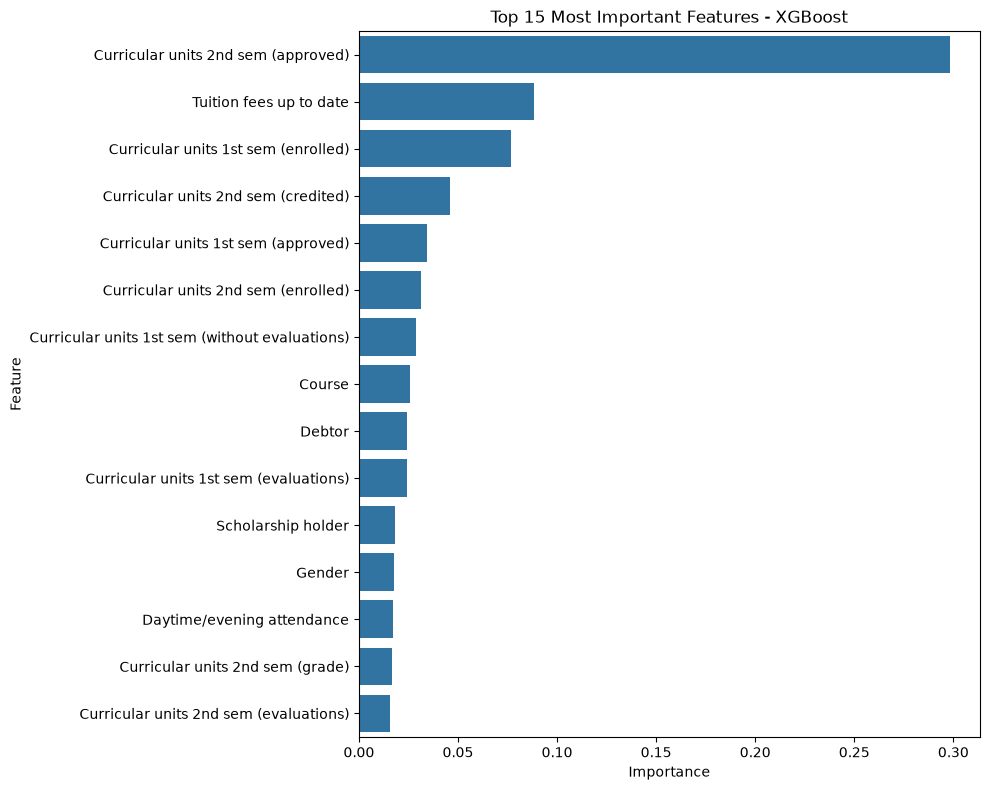

In [92]:
import os
import warnings
warnings.filterwarnings("ignore")

os.makedirs("../results/XGBoost_baseline", exist_ok=True)

feature_importance["Feature"] = feature_importance["Feature"].str.replace("\t", "")

plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features - XGBoost")
plt.tight_layout()

plt.savefig(
    "../results/XGBoost_baseline/feature_importance_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

We can see from the feature importance plot that second-semester and first-semester curricular units (approved and grades), along with tuition fees, are the most influential factors in predicting whether a student will graduate or drop out.

# Confusion Matrix

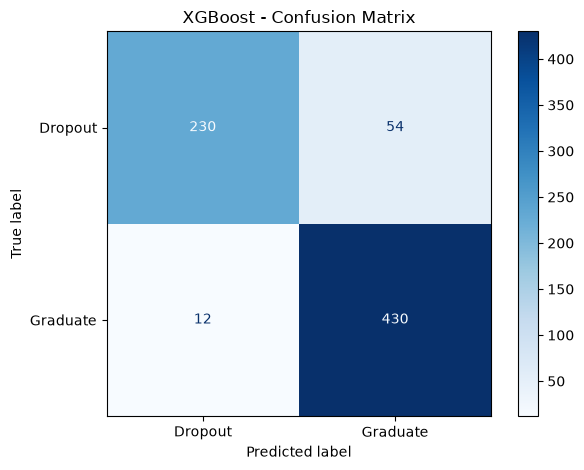

In [93]:
import os

os.makedirs("../results/XGBoost_baseline", exist_ok=True)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../results/XGBoost_baseline/confusion_matrix_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


We can see from the confusion matrix that the XGBoost model is highly accurate in distinguishing between the two student outcomes. Out of 726 test instances, the model correctly identified **430 Graduate** students (with only 12 misclassified as Dropout) and **230 Dropout** students (with 54 misclassified as Graduate). This demonstrates a strong predictive capability with very low false predictions across both classes.

### Observation

In this notebook, we implemented an **XGBoost** classifier as a strong baseline model for binary student dropout prediction (**Dropout** vs. **Graduate**). After filtering out the 'Enrolled' category, encoding the target variable, and splitting the dataset into 80% training (2,904 records) and 20% testing (726 records) sets, the model achieved an impressive overall **Accuracy of 90.08%**. 

In terms of class-specific performance, the model excelled in identifying **Graduate** students with a **Precision of 0.90**, **Recall of 0.94**, and an **F1-score of 0.92**. For the **Dropout** class, it also delivered strong results, achieving a **Precision of 0.90**, **Recall of 0.84**, and an **F1-score of 0.87** (with a macro average F1-score of **0.89** and weighted average F1-score of **0.90**). Furthermore, the feature importance analysis revealed that academic performance in the first two semesters—specifically **Curricular units 2nd sem (approved)** and **1st sem (enrolled/approved)**—along with financial factors like **Tuition fees up to date**, are the most influential predictors of student retention. Overall, this XGBoost model provides a reliable benchmark for comparing our future deep learning (LSTM) and Explainable AI (SHAP) architectures.